<a href="https://colab.research.google.com/github/VinceGarcia11/Melbourne_Housing/blob/main/Data_Mining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [125]:
import pandas as pd
from scipy import stats
from sklearn.cluster import KMeans
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.tools.tools as stattools
from sklearn.tree import DecisionTreeClassifier, export_graphviz, DecisionTreeRegressor
from sklearn.naive_bayes import MultinomialNB
from sklearn import tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import statsmodels.tools.tools as stattools
from sklearn.ensemble import RandomForestRegressor

#reading the data
url = "https://raw.githubusercontent.com/VinceGarcia11/Melbourne_Housing/refs/heads/main/melb_data.csv"
house = pd.read_csv(url)
house.head()


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000,S,Biggin,3/12/2016,2.5,3067,...,1,1.0,202,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019
1,Abbotsford,25 Bloomburg St,2,h,1035000,S,Biggin,4/2/2016,2.5,3067,...,1,0.0,156,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019
2,Abbotsford,5 Charles St,3,h,1465000,SP,Biggin,4/3/2017,2.5,3067,...,2,0.0,134,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019
3,Abbotsford,40 Federation La,3,h,850000,PI,Biggin,4/3/2017,2.5,3067,...,2,1.0,94,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019
4,Abbotsford,55a Park St,4,h,1600000,VB,Nelson,4/6/2016,2.5,3067,...,1,2.0,120,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019


**bold text**

In [126]:
#X
h = house.drop(['Address', 'Method', 'SellerG', 'Postcode'], axis=1)
h1 = pd.get_dummies( h, drop_first=True)
# Replacing NaN values with 0
X =  h1.fillna(0)


In [127]:
#categorical variable
#Create a random 80/20 split
#creating the split
x_train, x_test = train_test_split(X, test_size = 0.20, random_state = 7)


In [128]:
print(x_train.shape)
print(x_test.shape)

(10864, 423)
(2716, 423)


In [129]:
#Target Variable
y_train = x_train['Price']
#Target Variable
y_test = x_test['Price']

rf01 = RandomForestRegressor(n_estimators = 100, min_samples_leaf = 10, max_depth = 5).fit(x_train, y_train)
predict = rf01.predict(x_test)

In [130]:
# 1. R-Squared (0 to 1 scale, higher is better)
r2 = r2_score(y_test, predict) #generated by Gemini AI

# 2. Mean Absolute Error (Average dollar amount you are off by)
mae = mean_absolute_error(y_test, predict) #generated by Gemini AI

print(f"R2 Score: {r2:.4f}") #generated by Gemini AI
print(f"Average Error: ${mae:,.2f}") #generated by Gemini AI

R2 Score: 0.9944
Average Error: $10,543.45


In [131]:
print(f"Training Accuracy: {rf01.score(x_train, y_train):.2f}") #generated by Gemini to check accuracy

Training Accuracy: 1.00


In [132]:
cart01 = DecisionTreeClassifier(criterion = "gini", max_leaf_nodes=30).fit(x_train, y_train)

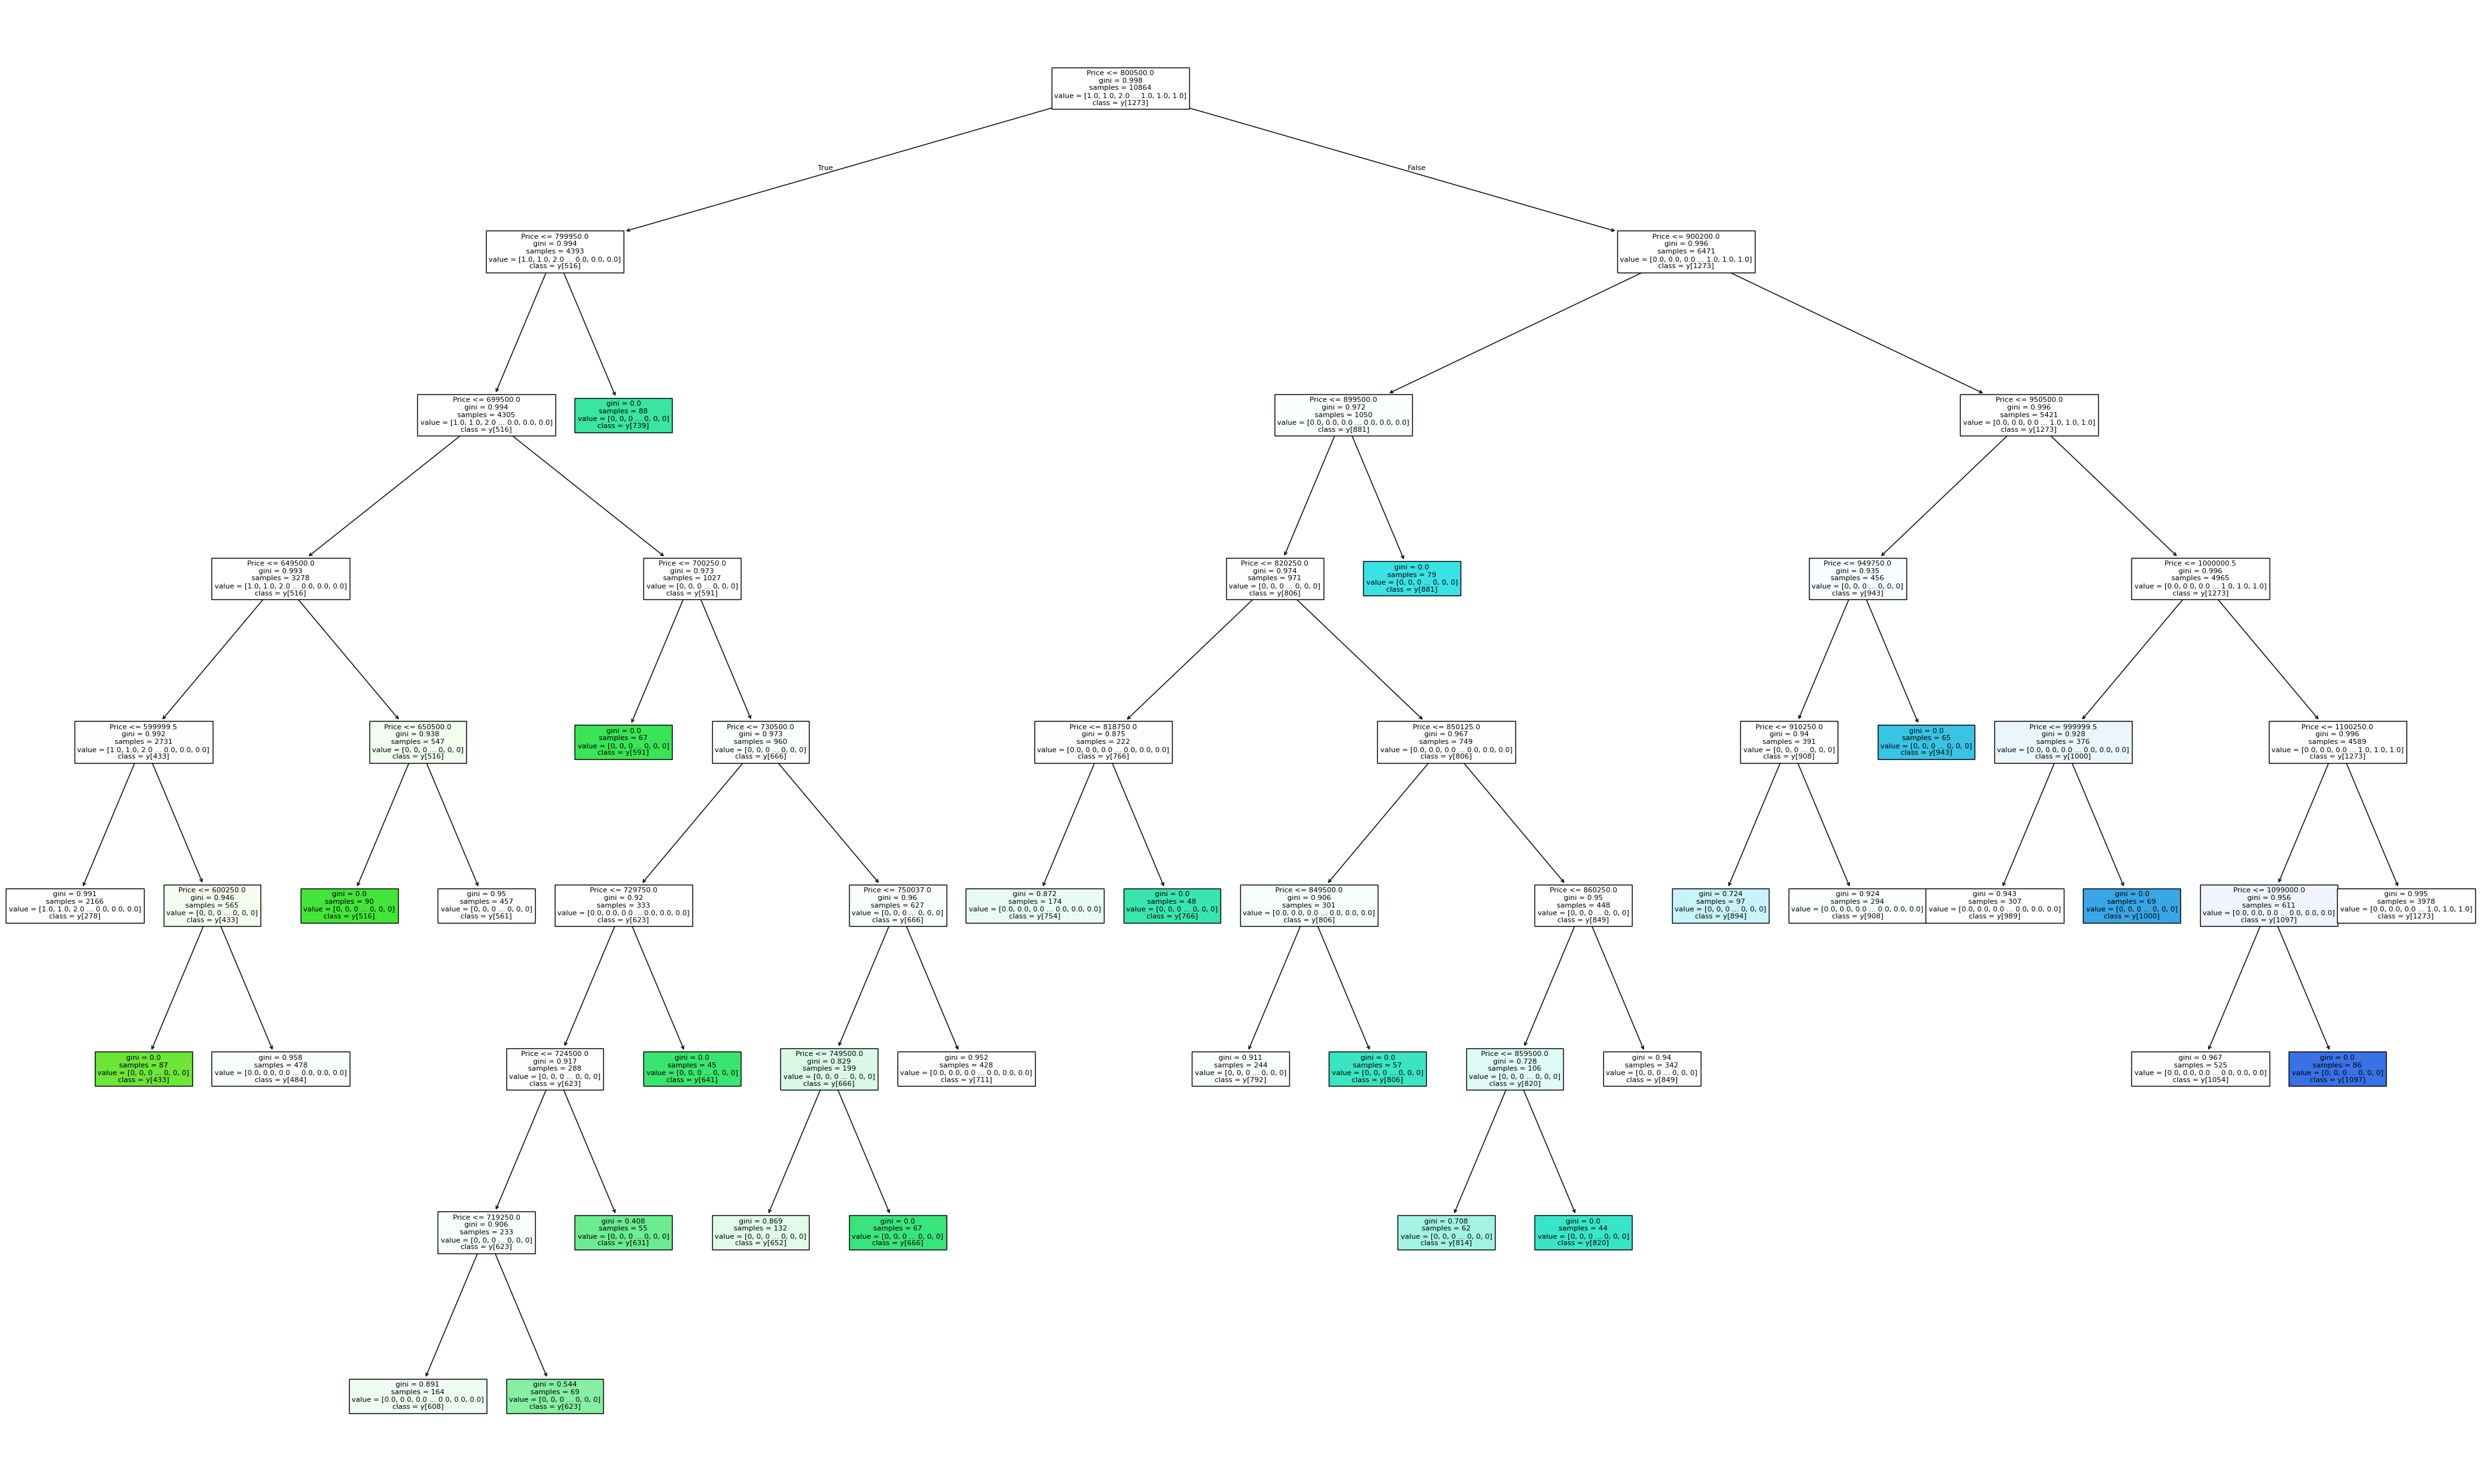

In [133]:
# Custom color function applied to nodes
fig, ax = plt.subplots(figsize=(50,30))
tree.plot_tree(cart01,
               feature_names=x_train.columns,
               class_names=True,
               filled=True,
               ax=ax)  # plot_tree doesn't directly support custom node functions, so this step remains simple
plt.show()
#source:
#https://www.geeksforgeeks.org/machine-learning/changing-colors-for-decision-tree-plot-using-sklearn-plot-tree/

In [134]:
# Create price/sq.ft. feature
house['price_per_sqft'] = house['Price'] / house['BuildingArea']

house = house.dropna(subset=['Price', 'BuildingArea', 'Regionname'])
house = house[house['BuildingArea'] > 0]

print(house.groupby('Regionname')['price_per_sqft'].describe())

                             count          mean           std          min  \
Regionname                                                                    
Eastern Metropolitan         708.0   9574.485161  33273.813628   188.484759   
Eastern Victoria              30.0   4517.782284   1589.979568   786.618445   
Northern Metropolitan       2090.0  12299.391950  52770.260581   261.382799   
Northern Victoria             28.0   3625.640609   1664.691556    30.439178   
South-Eastern Metropolitan   220.0   7701.725874  19814.806803   853.766617   
Southern Metropolitan       2409.0  14789.484298  89030.060858   474.695708   
Western Metropolitan        1607.0   8234.273167  20521.138092   707.142857   
Western Victoria              21.0   4061.400197   3443.223692  1600.000000   

                                    25%          50%           75%  \
Regionname                                                           
Eastern Metropolitan        5416.666667  6614.593230   8271.926338   

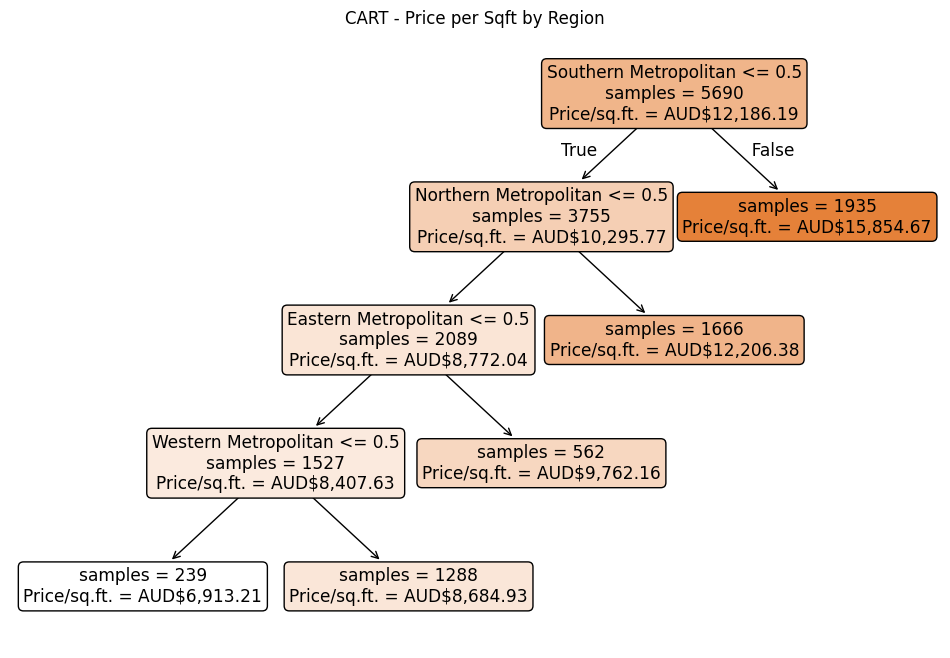

In [135]:
# CART
X = pd.get_dummies(house['Regionname'])
y_reg = house['price_per_sqft']

X_train, X_test, y_train, y_test = train_test_split(X, y_reg, test_size=0.2, random_state=42)

cart = DecisionTreeRegressor(max_depth=4, random_state=42)
cart.fit(X_train, y_train)

plt.figure(figsize=(12, 8))
plot_tree(cart, feature_names=X.columns.tolist(), filled=True, rounded=True, impurity=False)
plt.title("CART - Price per Sqft by Region")

for text_obj in plt.gca().texts:
    updated = text_obj.get_text().replace("value =", "Price/sq.ft. =")
    updated = re.sub(r"Price/sq.ft. = (\d+\.\d+)",
                     lambda m: f"Price/sq.ft. = AUD${float(m.group(1)):,.2f}",
                     updated)
    text_obj.set_text(updated)

plt.show()

In [139]:
# Naive-Bayes
house['price_tier'] = pd.qcut(house['price_per_sqft'], q=3, labels=['Low', 'Medium', 'High'])

t1 = pd.crosstab(house['Regionname'], house['price_tier'])
t1['Total'] = t1.sum(axis=1)
t1.loc['Total'] = t1.sum()
t1


price_tier,Low,Medium,High,Total
Regionname,,,,
Eastern Metropolitan,307,247,154,708
Eastern Victoria,27,3,0,30
Northern Metropolitan,757,662,671,2090
Northern Victoria,27,0,1,28
South-Eastern Metropolitan,132,64,24,220
Southern Metropolitan,251,914,1244,2409
Western Metropolitan,851,482,274,1607
Western Victoria,19,0,2,21
Total,2371,2372,2370,7113


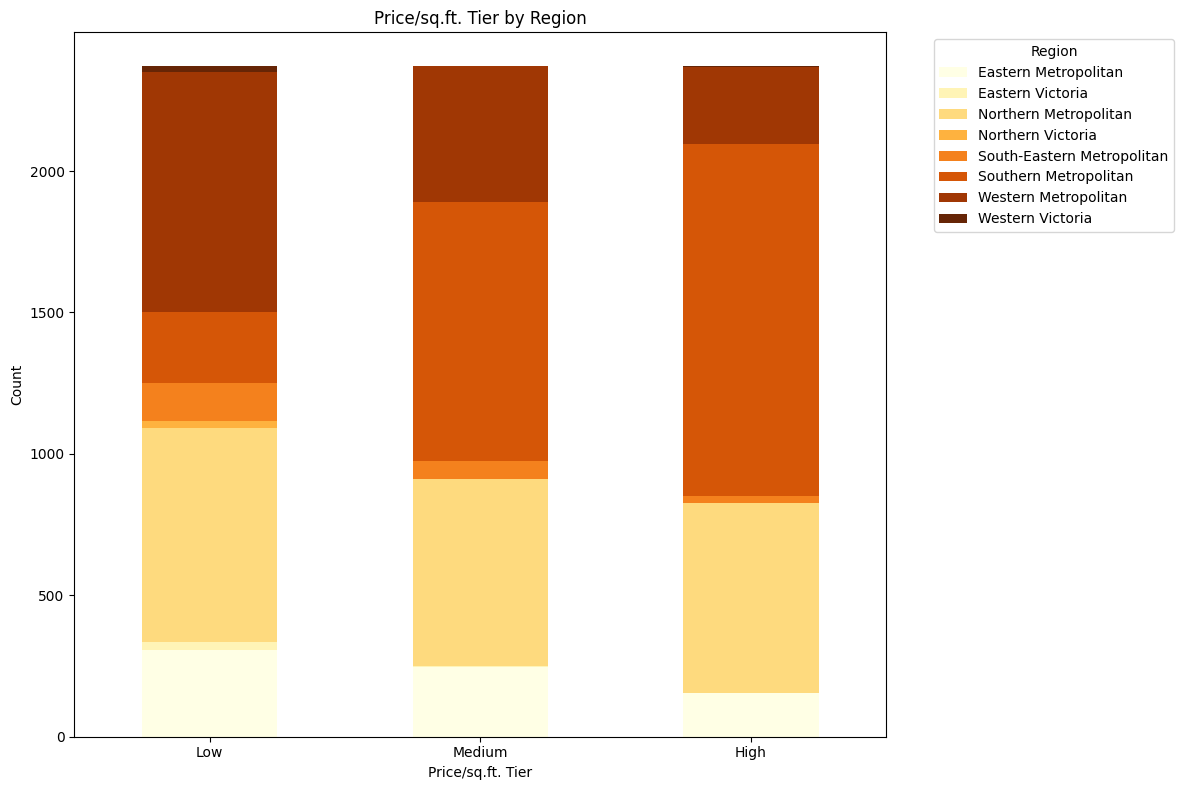

In [140]:
t1_plot = pd.crosstab(house['price_tier'], house['Regionname'])
t1_plot.plot(kind='bar', stacked=True, figsize=(12, 8), colormap='YlOrBr')
plt.title("Price/sq.ft. Tier by Region")
plt.xlabel("Price/sq.ft. Tier")
plt.ylabel("Count")
plt.legend(title="Region", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [141]:
X_price_ind = pd.get_dummies(house['price_tier'], drop_first=True).astype(float)
X_price_ind_dict = {i: col for i, col in enumerate(X_price_ind.columns)}

X_region_ind = pd.get_dummies(house['Regionname'], drop_first=True).astype(float)
X_region_ind_dict = {i: col for i, col in enumerate(X_region_ind.columns)}

X = pd.concat((X_price_ind, X_region_ind), axis=1)

print("Price tier mapping:", X_price_ind_dict)
print("Region mapping:", X_region_ind_dict)

Price tier mapping: {0: 'Medium', 1: 'High'}
Region mapping: {0: 'Eastern Victoria', 1: 'Northern Metropolitan', 2: 'Northern Victoria', 3: 'South-Eastern Metropolitan', 4: 'Southern Metropolitan', 5: 'Western Metropolitan', 6: 'Western Victoria'}


In [146]:
Y = house['price_tier']
nb_01 = MultinomialNB().fit(X, Y)

X_price_ind_test = pd.get_dummies(house['price_tier'], drop_first=True).astype(float)
X_region_ind_test = pd.get_dummies(house['Regionname'], drop_first=True).astype(float)

X_test = pd.concat((X_price_ind_test, X_region_ind_test), axis=1)

Y_predicted = nb_01.predict(X_test)
Y_predicted = pd.crosstab(house['price_tier'], Y_predicted, rownames=['Actual'], colnames=['Predicted'])
Y_predicted['Total'] = Y_predicted.sum(axis=1); Y_predicted.loc['Total'] = Y_predicted.sum(); Y_predicted

Predicted,High,Low,Medium,Total
Actual,,,,
Low,251,1813,307,2371
Medium,0,0,2372,2372
High,2370,0,0,2370
Total,2621,1813,2679,7113
